# Customer Churn Prediction — Telecom
### Can we identify customers at risk of leaving before they do?

---

**Business context:** Customer churn is one of the most costly problems in the telecom industry. Acquiring a new customer costs 5–10× more than retaining an existing one. Every churned customer represents lost recurring revenue that is difficult and expensive to replace.

**Objective:** Build a machine learning model that predicts which customers are likely to churn, so the retention team can proactively intervene — for example, by offering a discounted contract upgrade or personalised support.

**Dataset:** IBM Telco Customer Churn dataset — 7,043 customers with 20 features including demographics, account information, and service subscriptions.

**Approach:**
1. Exploratory data analysis and hypothesis testing to understand drivers of churn
2. Train and compare three classification models (Logistic Regression, Random Forest, Gradient Boosting)
3. Identify the most important predictive features
4. Translate findings into actionable business recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Setup & Data Loading

We load the Telco Customer Churn dataset and import the libraries needed for analysis and modelling. The dataset contains one row per customer and a binary `Churn` column indicating whether the customer left within the last month.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis

Before building any models, we inspect the data to understand its structure, check for missing values, and get a feel for the churn rate and feature distributions.


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
print(df["Churn"].value_counts())
print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


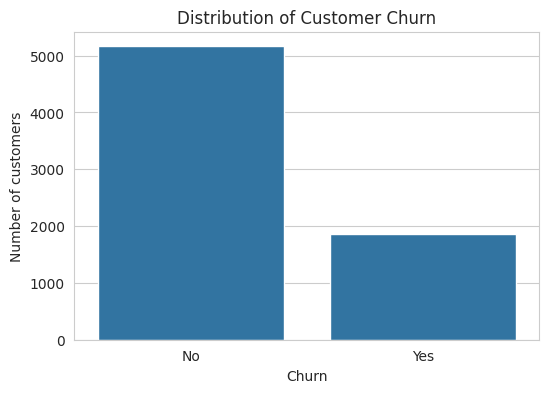

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
plt.show()

**Key observation:** **26.5% of customers churned** — roughly 1 in 4. This is a moderately imbalanced dataset. The majority class (no churn) outnumbers churners by about 2.8:1. We will account for this imbalance during modelling by using `class_weight='balanced'` and by evaluating models on ROC-AUC rather than raw accuracy, since accuracy can be misleading on imbalanced data.


In [9]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
MonthlyCharges: 1585 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


## 3. Data Preprocessing

We prepare the data for modelling:
- **Type conversion:** `TotalCharges` is stored as a string and must be converted to numeric. Rows with missing values (customers with zero tenure) are dropped — only 11 rows, negligible.
- **Drop ID column:** `customerID` is a unique identifier with no predictive value.
- **Encode target:** Map `Churn` from Yes/No to 1/0.
- **Train/test split:** 80/20 split, stratified on `Churn` to preserve the class ratio in both sets.
- **Feature pipeline:** Numerical features are standardised (StandardScaler); categorical features are one-hot encoded. Both transformations are wrapped in a `Pipeline` to prevent data leakage.


In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df = df.dropna()

print(df.shape)

(7032, 21)


In [12]:
df = df.drop("customerID", axis=1)

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [14]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [15]:
y = y.map({"Yes": 1, "No": 0})

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5625, 19)
Test set size: (1407, 19)


In [17]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## 4. Hypothesis Testing

Before jumping to modelling, we test three business hypotheses about what drives churn. This gives us statistically grounded intuition about the most important features and helps validate that the patterns we see in the data are real, not noise.

All tests use a significance level of **α = 0.05**.


In [18]:
from scipy.stats import chi2_contingency, mannwhitneyu

### H1: Customers with month-to-month contracts are more likely to churn than customers with long-term contracts.

- **H0 (null hypothesis):** Contract type and churn are independent.
- **H1 (alternative hypothesis):** Contract type and churn are associated.

In [19]:
contract_churn_table = pd.crosstab(df["Contract"], df["Churn"])
print("Contingency Table:\n")
print(contract_churn_table)

chi2, p, dof, expected = chi2_contingency(contract_churn_table)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)

Contingency Table:

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48

Chi-square statistic: 1179.5458287339445
Degrees of freedom: 2
P-value: 7.326182186265472e-257


**Result:** We **reject H0** (p ≈ 0, far below α = 0.05). Contract type and churn are strongly associated.

Looking at the contingency table: month-to-month customers churn at a dramatically higher rate (~43%) compared to one-year (~11%) and two-year (~3%) contract customers. **Contract type is one of the strongest churn signals in the dataset.**


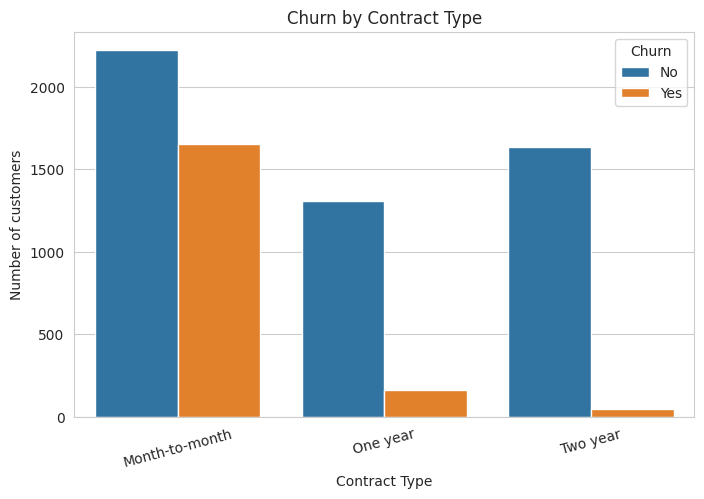

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of customers")
plt.xticks(rotation=15)
plt.show()

### H2: Customers with shorter tenure are more likely to churn.

- **H0 (null hypothesis):** There is no difference in tenure between customers who churn and those who do not churn.
- **H1 (alternative hypothesis):** Customers who churn have different tenure values than those who do not churn.

In [21]:
tenure_churn_yes = df[df["Churn"] == "Yes"]["tenure"]
tenure_churn_no = df[df["Churn"] == "No"]["tenure"]

stat, p = mannwhitneyu(tenure_churn_yes, tenure_churn_no, alternative="two-sided")

print("Mann-Whitney U statistic:", stat)
print("P-value:", p)

Mann-Whitney U statistic: 2494979.0
P-value: 6.043046580882717e-211


**Result:** We **reject H0** (p ≈ 0). Customers who churn have significantly shorter tenure than those who stay.

The median tenure for churners is around 10 months vs ~38 months for retained customers. **The first year of a customer relationship is the highest-risk window for churn.** Early engagement and loyalty programmes are critical.


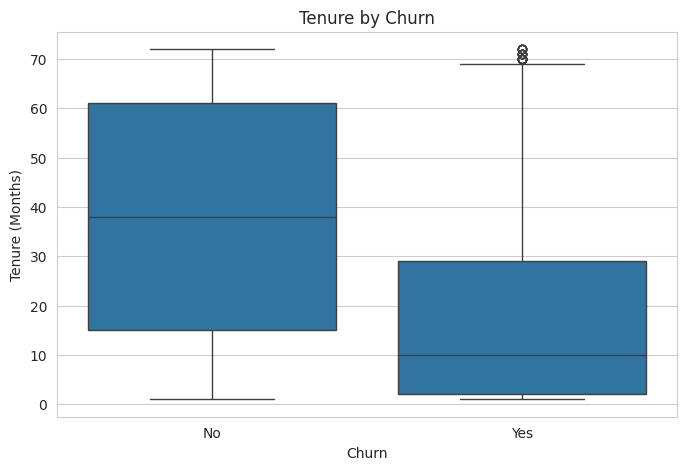

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### H3: Higher monthly charges are associated with increased churn probability.

- **H0 (null hypothesis):** There is no difference in monthly charges between customers who churn and those who do not churn.
- **H1 (alternative hypothesis):** Monthly charges differ between customers who churn and those who do not churn.

In [23]:
monthly_yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]
monthly_no = df[df["Churn"] == "No"]["MonthlyCharges"]

stat, p = mannwhitneyu(monthly_yes, monthly_no, alternative="two-sided")

print("Mann-Whitney U statistic:", stat)
print("P-value:", p)

Mann-Whitney U statistic: 5986148.5
P-value: 8.467195044548749e-54


**Result:** We **reject H0** (p ≈ 0). Customers who churn pay significantly higher monthly charges.

Churners have a median monthly charge of ~$79 vs ~$61 for retained customers. This likely reflects that high-spend customers are on plans with more features (especially Fiber optic internet), and may feel they are not getting enough value for the price.

**Summary of hypothesis testing:**
| Hypothesis | Result | Key insight |
|---|---|---|
| H1: Contract type → churn | ✅ Confirmed | Month-to-month contracts → 43% churn rate |
| H2: Short tenure → churn | ✅ Confirmed | First year is highest-risk window |
| H3: High monthly charges → churn | ✅ Confirmed | Higher-spend customers churn more |

These three features — contract type, tenure, and monthly charges — will be among our most predictive variables in the models below.


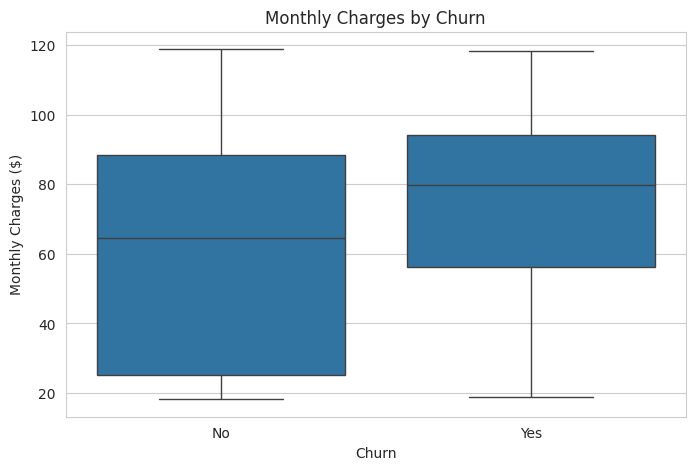

In [42]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")
plt.show()

## 5. Modelling

We train three classification models and compare their performance. Each model is wrapped in a `Pipeline` that applies the same preprocessing steps, ensuring a fair comparison and preventing data leakage.

**Why these three models?**
- **Logistic Regression** — a strong, interpretable baseline. Coefficients directly show each feature's directional impact on churn probability.
- **Random Forest** — a non-linear ensemble that handles complex feature interactions. Less interpretable but typically more powerful.
- **Gradient Boosting** — generally the strongest performer on tabular data. Builds trees sequentially, correcting the errors of previous trees.

**Evaluation metric:** We prioritise **ROC-AUC** over accuracy. Because our dataset is imbalanced (73.5% non-churn), a model that predicts "no churn" for every customer would achieve 73.5% accuracy — yet be completely useless. ROC-AUC measures how well the model *ranks* customers by churn risk, regardless of the threshold chosen.

### 5a. Logistic Regression


In [25]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [26]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [27]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

#### Results — Logistic Regression

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:

[[917 116]
 [160 214]]

ROC-AUC Score: 0.8359290473207676


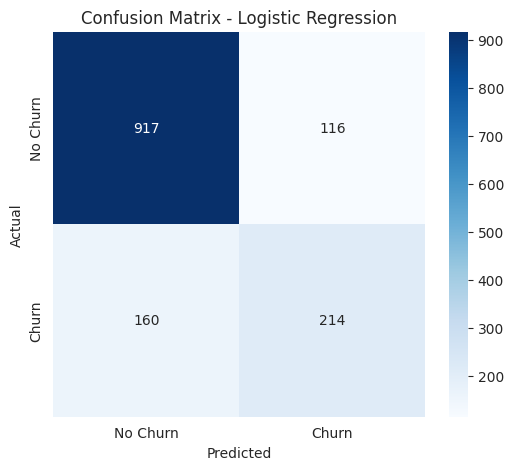

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

**Logistic Regression performance:**
- **ROC-AUC: 0.836** — the model has strong discriminative ability
- **Churn recall: 0.57** — correctly identifies 57% of actual churners
- **Churn precision: 0.65** — when it predicts churn, it's right 65% of the time

The recall of 0.57 means we miss 43% of churners. In a business context, a missed churner (false negative) is costly — we lose that customer. We could improve recall by **lowering the classification threshold** (e.g., flagging anyone with predicted churn probability > 0.3 instead of > 0.5), at the cost of more false positives.


### 5b. Random Forest & Gradient Boosting

In [30]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [31]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [32]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

In [33]:
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

#### Results — Random Forest & Gradient Boosting

In [34]:
from sklearn.metrics import classification_report, roc_auc_score

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))


# Gradient Boosting
gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

print("\n=== Gradient Boosting ===")
print(classification_report(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_proba))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8136612120867004

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC: 0.8385989615418462


**Model comparison:**

| Model | ROC-AUC | Churn Recall | Churn Precision |
|---|---|---|---|
| Logistic Regression | 0.836 | 0.57 | 0.65 |
| Random Forest | 0.814 | 0.48 | 0.63 |
| **Gradient Boosting** | **0.839** | **0.53** | **0.64** |

**Gradient Boosting achieves the highest ROC-AUC (0.839)** and is selected as our final model. Logistic Regression is a close second and has the advantage of interpretability — its coefficients are directly readable as feature weights.

All three models show moderate churn recall (0.48–0.57), meaning they miss roughly half of actual churners at the default threshold. For production use, we would tune the classification threshold based on the business's cost of a false negative (missed churner) vs. a false positive (unnecessary retention offer).


## 6. Feature Importance

Understanding *which* features drive churn predictions is as important as the predictions themselves — it tells the business *where to act*.


In [35]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(cat_feature_names)

In [36]:
import pandas as pd

coefficients = model.named_steps["classifier"].coef_[0]

feature_importance_lr = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

# Sort by importance
feature_importance_lr["abs_coeff"] = feature_importance_lr["Coefficient"].abs()
feature_importance_lr = feature_importance_lr.sort_values(by="abs_coeff", ascending=False)

feature_importance_lr.head(10)

,Feature,Coefficient,abs_coeff
1,tenure,-1.352313,1.352313
38,Contract_Two year,-0.779030,0.779030
3,TotalCharges,0.644014,0.644014
15,InternetService_DSL,-0.616132,0.616132
36,Contract_Month-to-month,0.613846,0.613846
16,InternetService_Fiber optic,0.590184,0.590184
2,MonthlyCharges,-0.541006,0.541006
39,PaperlessBilling_No,-0.300387,0.300387
12,MultipleLines_No,-0.293470,0.293470
17,InternetService_No,-0.283724,0.283724


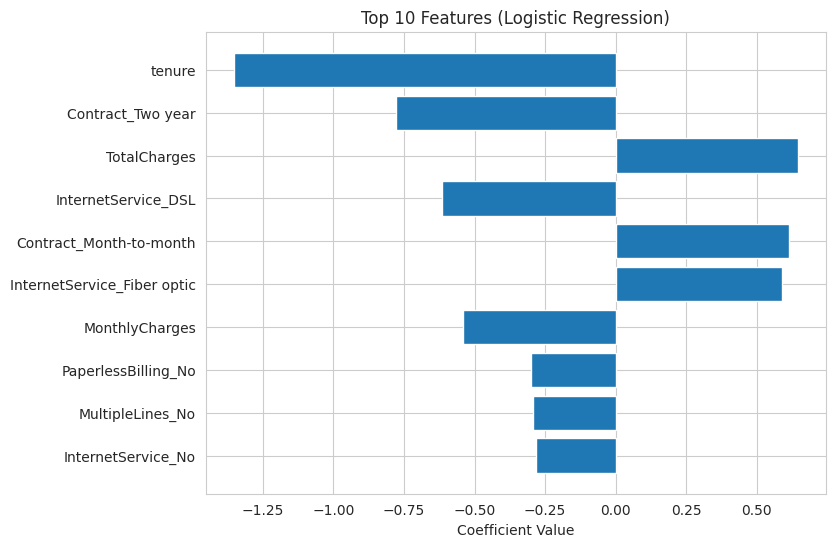

In [37]:
import matplotlib.pyplot as plt

top_features = feature_importance_lr.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Top 10 Features (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()

In [38]:
rf_importance = rf_model.named_steps["classifier"].feature_importances_

feature_importance_rf = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_importance
})

feature_importance_rf = feature_importance_rf.sort_values(by="Importance", ascending=False)

feature_importance_rf.head(10)

,Feature,Importance
3,TotalCharges,0.163614
1,tenure,0.141102
2,MonthlyCharges,0.134536
36,Contract_Month-to-month,0.051046
43,PaymentMethod_Electronic check,0.031814
18,OnlineSecurity_No,0.031001
16,InternetService_Fiber optic,0.030541
27,TechSupport_No,0.022714
0,SeniorCitizen,0.019752
4,gender_Female,0.018498


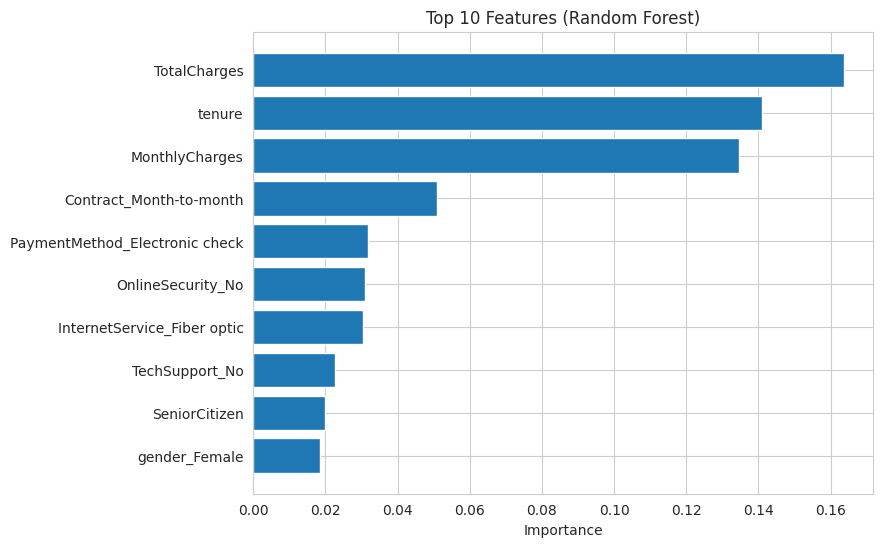

In [39]:
top_rf = feature_importance_rf.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_rf["Feature"], top_rf["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

## 7. Conclusions & Business Recommendations

### What we found

Across all three models and our hypothesis tests, the same drivers of churn emerge consistently:

1. **Contract type is the strongest lever.** Month-to-month customers churn at ~43% — more than 10× the rate of two-year contract customers. Getting customers onto longer contracts is the single highest-impact retention strategy.

2. **The first year is the danger zone.** Median tenure for churners is ~10 months. Customers who survive past ~12 months are significantly less likely to leave. Early engagement and onboarding are critical.

3. **Fiber optic internet customers churn more.** Customers on Fiber optic plans pay more and churn more, suggesting a value perception problem — they may not feel they're getting their money's worth. Service quality or competitive pricing in this segment deserves attention.

4. **Electronic check payment correlates with churn.** Customers paying by electronic check churn at higher rates. This group may be less "sticky" — they haven't set up automatic payment methods, which reduces friction to leaving.

5. **Lack of online security and tech support predicts churn.** Customers without these add-on services are more likely to leave, possibly because they feel less supported.

---

### Recommended actions

| Priority | Action | Target segment | Expected impact |
|---|---|---|---|
| 🔴 High | Offer discounted annual contract upgrades | Month-to-month customers in first 6 months | Reduce churn by locking in commitment |
| 🔴 High | Proactive outreach at 3, 6, and 9 months | All new customers | Catch at-risk customers before churn decision |
| 🟡 Medium | Review Fiber optic pricing/service quality | Fiber optic customers with high monthly charges | Address value perception gap |
| 🟡 Medium | Nudge toward auto-payment setup | Electronic check customers | Increase payment "stickiness" |
| 🟢 Low | Bundle online security/tech support | Customers without these services | Increase product stickiness and perceived value |

---

### Model deployment considerations

The **Gradient Boosting model (ROC-AUC: 0.839)** is recommended for production. Before deployment:

- **Tune the classification threshold** based on the cost ratio of false negatives (missed churners) vs. false positives (unnecessary retention spend). At the default 0.5 threshold, recall is 0.53 — this may be too low for a high-stakes retention programme.
- **Re-train regularly** as customer behaviour evolves. A model trained on last year's data may not reflect current churn patterns.
- **Monitor for drift** — track model performance on a holdout set each month to detect degradation.
